In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.sparse import hstack
 

In [2]:
"""
attempted email dataset integration but it reduced accuracy due to domain mismatch between 
SMS and corporate email language.
"""

'\nattempted email dataset integration but it reduced accuracy due to domain mismatch between \nSMS and corporate email language.\n'

In [3]:
df1 = pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "text"])
df2 = pd.read_csv("spam.csv", encoding="latin-1")

In [4]:
df1.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df2.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df2 = df2[["v1", "v2"]] 
df2.columns = ["label", "text"] 
df = pd.concat([df1, df2], ignore_index=True) 
df = df.drop_duplicates()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

In [8]:
# Add Indian fraud SMS samples
indian_fraud = pd.DataFrame({
    "label": [1] * 10,         # label all the 10 testcases as fraud 
    "text": [
        "Dear customer your KYC is expired. Update now at http://kyc-sbi.xyz to avoid block.",
        "Your UPI PIN is compromised. Call 9876543210 immediately to secure account.",
        "Income tax refund Rs15000 pending. Click http://incometax-refund.in to claim now.",
        "TRAI will deactivate your SIM. Update Aadhaar details at http://trai-kyc.com",
        "Congratulations! You won Rs500000 in BSNL lucky draw. Call 9123456789 to claim.",
        "Your HDFC credit card is blocked. Verify CVV and card number at http://hdfc-verify.net",
        "Earn Rs5000 daily from home. No investment. WhatsApp 9876543210 to join now.",
        "Dear SBI user your account will be closed. Complete KYC at http://sbi-update.xyz",
        "You have been selected for government scheme Rs10000. Send Aadhaar to 9988776655.",
        "Paytm KYC pending your wallet will be blocked. Verify at http://paytm-kyc.xyz"
    ]
})
df = pd.concat([df, indian_fraud], ignore_index=True)

# Safety check — ensure no unmapped labels remain
print(f"Label types: {df['label'].dtype}")
print(f"Unique labels: {df['label'].unique()}")
print(f"NaN labels: {df['label'].isna().sum()}")

Label types: int64
Unique labels: [0 1]
NaN labels: 0


In [9]:
df

,label,text
0,0,Oooh I got plenty of those!
1,0,"No idea, I guess we'll work that out an hour a..."
2,0,Ard 6 like dat lor.
3,0,Please dont say like that. Hi hi hi
4,0,"Aight, text me tonight and we'll see what's up"
...,...,...
5730,1,Your HDFC credit card is blocked. Verify CVV a...
5731,1,Earn Rs5000 daily from home. No investment. Wh...
5732,1,Dear SBI user your account will be closed. Com...
5733,1,You have been selected for government scheme R...


In [10]:
spam = df[df.label == 1]
ham  = df[df.label == 0]
spam_upsampled = resample(spam, replace=True, n_samples=len(ham), random_state=42)
df = pd.concat([ham, spam_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
print(df["label"].value_counts())

label
0    4844
1    4844
Name: count, dtype: int64


In [12]:
df


,label,text
0,0,Do have a nice day today. I love you so dearly.
1,1,Free 1st week entry 2 TEXTPOD 4 a chance 2 win...
2,0,Ok i wont call or disturb any one. I know all ...
3,1,Are you unique enough? Find out from 30th Augu...
4,0,"Forgot you were working today! Wanna chat, but..."
...,...,...
9683,1,Get a FREE mobile video player FREE movie. To ...
9684,1,Reply with your name and address and YOU WILL ...
9685,1,Congratulations ur awarded either å£500 of CD ...
9686,0,"Goodnight, sleep well da please take care pa. ..."


In [13]:
from sklearn.model_selection import train_test_split

# Step 1: Split FIRST (before any upsampling)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df["text"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Step 2: Upsample ONLY the training set
train_df = pd.concat([X_train_raw, y_train_raw], axis=1)
spam_tr  = train_df[train_df.label == 1]
ham_tr   = train_df[train_df.label == 0]
spam_up  = resample(spam_tr, replace=True, n_samples=len(ham_tr), random_state=42)
train_df = pd.concat([ham_tr, spam_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train size : {len(train_df)}  |  {train_df['label'].value_counts().to_dict()}")
print(f"Test  size : {len(X_test_raw)}")

Train size : 7750  |  {0: 3875, 1: 3875}
Test  size : 1938


In [14]:
import re

def preprocess_text(text):
    msg = str(text).lower()

    # Normalize common obfuscations used in spam
    msg = msg.replace("@", "a")         # fr@ud → fraud
    msg = msg.replace("0", "o")         # 0tp → otp
    msg = msg.replace("1", "i")         # 1ncome → income
    msg = msg.replace("$", "s")         # ca$h → cash
    msg = msg.replace("3", "e")         # fr3e → free

    # Remove extra whitespace
    msg = re.sub(r'\s+', ' ', msg).strip()

    # Feature flags (used in numeric features)
    url     = 1 if ("http" in msg or "www" in msg or "bit.ly" in msg
                    or "tinyurl" in msg) else 0
    money   = 1 if any(c in msg for c in ["rs", "₹", "£", "$", "inr",
                                           "lakh", "crore"]) else 0
    urgency = 1 if any(w in msg for w in ["urgent", "immediately", "hurry",
                                           "asap", "expire", "act now",
                                           "last chance"]) else 0
    return msg, url, money, urgency

def add_features(data_df):
    """Add numeric features to a dataframe that has a 'text' column."""
    data_df = data_df.copy()
    data_df["length"]      = data_df["text"].apply(len)
    data_df["num_digits"]  = data_df["text"].str.count(r"\d")
    data_df["has_link"]    = data_df["text"].str.contains(r"http|www|bit\.ly", na=False).astype(int)
    data_df["has_money"]   = data_df["text"].str.contains(r"rs|₹|£|\$|inr|lakh|crore",
                                                           na=False, case=False).astype(int)
    data_df["has_urgency"] = data_df["text"].str.contains(
                                 "urgent|immediately|hurry|expire|asap",
                                 na=False, case=False).astype(int)
    data_df["num_caps"]    = data_df["text"].apply(lambda x: sum(1 for c in x if c.isupper()))
    data_df["num_special"] = data_df["text"].apply(lambda x: len(re.findall(r'[!?@#%]', x)))
    return data_df

# Apply features to both splits
train_df    = add_features(train_df)
test_df     = pd.DataFrame({"text": X_test_raw, "label": y_test_raw}).reset_index(drop=True)
test_df     = add_features(test_df)

FEATURE_COLS = ["length", "num_digits", "has_link", "has_money",
                "has_urgency", "num_caps", "num_special"]

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    stop_words="english",
    analyzer="word",
    strip_accents="unicode",
    token_pattern=r"\b[a-z]{2,}\b"
)

# Preprocess text before vectorizing
X_train_clean = train_df["text"].apply(lambda x: preprocess_text(x)[0])
X_test_clean  = test_df["text"].apply(lambda x: preprocess_text(x)[0])

X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_test_tfidf  = vectorizer.transform(X_test_clean)

X_train = hstack([X_train_tfidf, train_df[FEATURE_COLS].values])
X_test  = hstack([X_test_tfidf,  test_df[FEATURE_COLS].values])

y_train = train_df["label"]
y_test  = test_df["label"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (7750, 8007)
X_test  shape: (1938, 8007)


In [16]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    {"C": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="f1", n_jobs=-1
)
lr_grid.fit(X_train, y_train)
lr_model = lr_grid.best_estimator_
lr_f1    = f1_score(y_test, lr_model.predict(X_test))
print(f"Logistic Regression → Best C: {lr_grid.best_params_}  |  F1: {lr_f1:.4f}")

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    {"n_estimators": [100, 200], "max_depth": [None, 20]},
    cv=5, scoring="f1", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_f1    = f1_score(y_test, rf_model.predict(X_test))
print(f"Random Forest       → Best params: {rf_grid.best_params_}  |  F1: {rf_f1:.4f}")

# XGBoost — works well with sparse TF-IDF + dense feature mix
# scale_pos_weight handles class imbalance automatically
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_grid = GridSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale,
        random_state=42,
        tree_method="hist",       # fast histogram method, works on CPU and GPU
        n_jobs=-1
    ),
    {
        "n_estimators":    [100, 300],
        "max_depth":       [4, 6],
        "learning_rate":   [0.05, 0.1],
        "subsample":       [0.8],
        "colsample_bytree":[0.8]
    },
    cv=5, scoring="f1", n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_model = xgb_grid.best_estimator_
xgb_f1    = f1_score(y_test, xgb_model.predict(X_test))
print(f"XGBoost             → Best params: {xgb_grid.best_params_}  |  F1: {xgb_f1:.4f}")

# Auto-pick the best model
scores = {"Logistic Regression": (lr_f1, lr_model),
          "Random Forest":       (rf_f1, rf_model),
          "XGBoost":             (xgb_f1, xgb_model)}

best_name, (best_f1, model) = max(scores.items(), key=lambda x: x[1][0])
print(f"\nSelected: {best_name}  (F1={best_f1:.4f})")

Logistic Regression → Best C: {'C': 100}  |  F1: 0.9969
Random Forest       → Best params: {'max_depth': None, 'n_estimators': 100}  |  F1: 0.9990
XGBoost             → Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}  |  F1: 0.9918

Selected: Random Forest  (F1=0.9990)


In [17]:
import pickle

# Save model and vectorizer
with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("fraud_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# Also save model name so you know what was selected
with open("fraud_model_info.txt", "w") as f:
    f.write(f"Selected model : {best_name}\n")
    f.write(f"F1 scores      : LR={lr_f1:.4f}  RF={rf_f1:.4f}  XGB={xgb_f1:.4f}\n")

print(f"Model saved      → fraud_model.pkl")
print(f"Vectorizer saved → fraud_vectorizer.pkl")
print(f"Model info saved → fraud_model_info.txt")

Model saved      → fraud_model.pkl
Vectorizer saved → fraud_vectorizer.pkl
Model info saved → fraud_model_info.txt


In [18]:
import pickle

with open("fraud_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("fraud_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

print(f"Model loaded      — type: {type(model).__name__}")
print(f"Vectorizer loaded — vocab size: {len(vectorizer.vocabulary_)}")

Model loaded      — type: RandomForestClassifier
Vectorizer loaded — vocab size: 8000


Accuracy  : 0.9990
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       969
           1       1.00      1.00      1.00       969

    accuracy                           1.00      1938
   macro avg       1.00      1.00      1.00      1938
weighted avg       1.00      1.00      1.00      1938



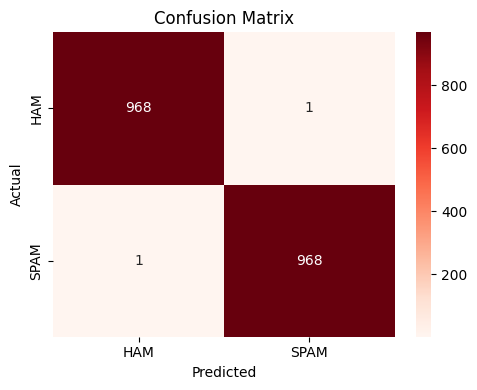

In [19]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["HAM", "SPAM"],
            yticklabels=["HAM", "SPAM"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [20]:
import pickle

# Save the real trained 
pickle.dump({"model": model, "vectorizer": vectorizer}, open("final.pkl", "wb"))
print(f"Model saved — expects {model.n_features_in_} features")


Model saved — expects 8007 features


In [22]:
def extract_signals(text):
    msg = text.lower()
    signals = []
    # OTP scam
    if "otp" in msg:
        signals.append("OTP_SCAM")
    # Account threat
    if any(p in msg for p in [
        "account blocked", "account suspended", "account deactivated",
        "account on hold", "account will be closed", "account disabled",
        "account frozen", "account terminated"
    ]):
        signals.append("ACCOUNT_THREAT")
    # Phishing attempt
    if any(p in msg for p in [
        "verify", "verification", "confirm your", "update your",
        "validate", "reactivate", "re-verify", "re-confirm",
        "complete your kyc", "kyc pending", "kyc expired",
        "submit your details", "enter your details"
    ]):
        signals.append("PHISHING_ATTEMPT")
    # Suspicious link
    if any(p in msg for p in [
        "http", "www", "bit.ly", "tinyurl", "t.co",
        "shorturl", "ow.ly", "rb.gy", "cutt.ly", "tiny.cc"
    ]):
        signals.append("SUSPICIOUS_LINK")
    # Prize bait
    if any(p in msg for p in [
        "won", "winner", "prize", "lottery", "lucky draw",
        "you have been selected for prize", "selected as winner",
        "chosen as winner", "chosen for reward",
        "reward", "gift card", "voucher",
        "cashback offer", "special offer", "exclusive offer",
        "bumper prize", "jackpot", "spin and win",
        "congratulations", "claim your prize", "claim now",
        "call now to claim", "collect your reward"
    ]):
        signals.append("PRIZE_BAIT")
    # Bank / credential fraud
    if any(p in msg for p in [
        "card number", "cvv", "expiry date", "card details",
        "net banking", "internet banking", "bank login",
        "bank account number", "ifsc", "debit card", "credit card",
        "atm pin", "pin number", "card pin", "upi pin",
        "upi id", "google pay", "phonepe", "paytm"
    ]):
        signals.append("BANK_FRAUD")
    # Credential theft
    if any(p in msg for p in [
        "password", "username", "login", "sign in", "user id",
        "aadhar", "aadhaar", "pan card", "pan number",
        "date of birth", "dob", "mother's maiden", "security question"
    ]):
        signals.append("CREDENTIAL_THEFT")
    # Impersonation
    if any(p in msg for p in [
        "rbi", "reserve bank", "sebi", "income tax", "it department",
        "irdai", "trai", "government of india", "ministry",
        "police", "cyber crime", "court notice", "legal notice",
        "uidai", "npci", "sbi", "hdfc", "icici", "axis bank",
        "amazon", "flipkart", "swiggy", "zomato", "irctc",
        "airtel", "jio", "bsnl", "vodafone"
    ]):
        signals.append("IMPERSONATION")
    # Money mule / transfer scam
    if any(p in msg for p in [
        "transfer now", "send money", "transfer money", "wire transfer",
        "pay now", "payment pending", "pay immediately",
        "deposit now", "fund your wallet", "recharge now",
        "processing fee", "registration fee", "advance fee",
        "tax fee", "customs fee", "release fee", "handling fee"
    ]):
        signals.append("MONEY_SCAM")
    # Job / investment scam
    if any(p in msg for p in [
        "work from home", "earn daily", "earn weekly",
        "part time job", "data entry job", "typing job",
        "investment opportunity", "high returns", "guaranteed returns",
        "double your money", "triple your money", "profit guaranteed",
        "no risk investment", "crypto investment", "trading profit",
        "refer and earn", "mlm", "network marketing"
    ]):
        signals.append("JOB_INVESTMENT_SCAM")
    # Urgency pressure
    if any(p in msg for p in [
        "urgent", "immediately", "right now", "hurry",
        "last chance", "final notice", "expire today",
        "expires in", "limited time", "act now", "do it now",
        "within 24 hours", "within 2 hours", "before midnight",
        "today only", "don't delay", "asap"
    ]):
        signals.append("URGENCY_PRESSURE")
    return signals

In [23]:
def predict_message(text):
    cleaned, url, money, urgency = preprocess_text(text)

    tfidf_vec  = vectorizer.transform([cleaned])

    length      = len(text)
    num_digits  = sum(c.isdigit() for c in text)
    num_caps    = sum(1 for c in text if c.isupper())
    num_special = len(re.findall(r'[!?@#%]', text))

    # Must match training order:
    # ["length", "num_digits", "has_link", "has_money", "has_urgency",
    #  "num_caps", "num_special"]
    extra = np.array([[length, num_digits, url, money, urgency,
                       num_caps, num_special]])

    final_input = hstack([tfidf_vec, extra])

    pred  = model.predict(final_input)[0]
    proba = model.predict_proba(final_input)[0]
    conf  = proba.max()
    return pred, conf

In [24]:
def generate_explanation(label, signals):
    if signals:
        return f"Detected {', '.join(signals)} — indicates potential {label.lower()} behavior."
    return "No strong fraud indicators detected by rule engine; classified by ML model."

In [27]:
def analyze_message(text):
    cleaned, url, money, urgency = preprocess_text(text)
    pred, conf = predict_message(text)
    signals    = extract_signals(cleaned)
    msg        = text.lower()

    # ── SAFE OTP override ────────────────────────────────────────────────
    otp_safe_phrases = [
        "do not share", "don't share", "dont share",
        "never share", "do not disclose", "don't disclose",
        "never disclose", "not share", "do not reveal", "don't reveal"
    ]
    otp_triggers = ["otp", "verification code", "security code", "login code", "one-time password"]

    if any(t in msg for t in otp_triggers) and any(p in msg for p in otp_safe_phrases):
        return {
            "classification": "SAFE",
            "confidence":      round(conf, 3),
            "signals":         [],
            "explanation":     "Legitimate OTP message — contains privacy/safety warning."
        }

    # ── SAFE transactional override ──────────────────────────────────────
    safe_patterns = [
        "debited", "credited", "delivered", "shipment",
        "out for delivery", "order #", "txn id", "upi ref",
        "bill due", "emi due"
    ]
    if any(p in msg for p in safe_patterns) and not signals:
        return {
            "classification": "SAFE",
            "confidence":      round(conf, 3),
            "signals":         signals,
            "explanation":     "Legitimate transactional message."
        }

    # ── Bill / EMI safe override ──────────────────────────────────────────
    bill_safe_patterns = [
        "bill due", "bill of rs", "bill of ₹",
        "emi due", "emi of rs", "emi of ₹",
        "statement due", "minimum due", "payment due"
    ]
    dangerous = {"SUSPICIOUS_LINK", "PRIZE_BAIT", "MONEY_SCAM", "URGENCY_PRESSURE"}
    if any(p in msg for p in bill_safe_patterns) and not any(s in signals for s in dangerous):
        return {
            "classification": "SAFE",
            "confidence":      round(conf, 3),
            "signals":         [],
            "explanation":     "Legitimate bill or EMI notification."
        }

    # ── Expand PRIZE_BAIT ────────────────────────────────────────────────
    prize_words = [
        "winner", "lucky", "won", "prize", "reward", "lottery",
        "congratulations", "claim now", "call now to claim",
        "bumper prize", "jackpot", "spin and win", "gift card"
    ]
    if any(w in msg for w in prize_words):
        if "PRIZE_BAIT" not in signals:
            signals.append("PRIZE_BAIT")

    # ── Signal flags ─────────────────────────────────────────────────────
    has_link     = "SUSPICIOUS_LINK"     in signals
    has_prize    = "PRIZE_BAIT"          in signals
    has_phishing = "PHISHING_ATTEMPT"    in signals
    has_account  = "ACCOUNT_THREAT"      in signals
    has_bank     = "BANK_FRAUD"          in signals
    has_cred     = "CREDENTIAL_THEFT"    in signals
    has_imperso  = "IMPERSONATION"       in signals
    has_money    = "MONEY_SCAM"          in signals
    has_urgency  = "URGENCY_PRESSURE"    in signals
    has_job      = "JOB_INVESTMENT_SCAM" in signals
    has_otp      = "OTP_SCAM"            in signals

    # ── COMBINATION rules (two signals together = always FRAUD) ──────────
    if   has_link and has_prize:                label = "FRAUD"; conf = max(conf, 0.97)
    elif has_link and has_phishing:             label = "FRAUD"; conf = max(conf, 0.96)
    elif has_link and has_account:              label = "FRAUD"; conf = max(conf, 0.95)
    elif has_link and has_bank:                 label = "FRAUD"; conf = max(conf, 0.95)
    elif has_link and has_cred:                 label = "FRAUD"; conf = max(conf, 0.95)
    elif has_link and has_imperso:              label = "FRAUD"; conf = max(conf, 0.92)
    elif has_link and has_urgency:              label = "FRAUD"; conf = max(conf, 0.90)
    elif has_link and has_otp:                  label = "FRAUD"; conf = max(conf, 0.90)
    elif has_phishing and has_urgency:          label = "FRAUD"; conf = max(conf, 0.88)
    elif has_account  and has_urgency:          label = "FRAUD"; conf = max(conf, 0.88)
    elif has_imperso  and has_urgency:          label = "FRAUD"; conf = max(conf, 0.88)
    elif has_bank     and has_urgency:          label = "FRAUD"; conf = max(conf, 0.90)
    elif has_cred     and has_urgency:          label = "FRAUD"; conf = max(conf, 0.90)

    # ── Single signal rules ───────────────────────────────────────────────
    elif has_prize:
        label = "FRAUD"; conf = max(conf, 0.80)
    elif has_money and pred == 1:               label = "FRAUD";      conf = max(conf, 0.90)
    elif has_job   and pred == 1:               label = "FRAUD";      conf = max(conf, 0.88)
    elif has_bank  or has_cred:
        label = "FRAUD" if pred == 1 else "SUSPICIOUS"; conf = max(conf, 0.80)
    elif has_imperso:
        label = "SUSPICIOUS";  conf = max(conf, 0.78)
    elif has_phishing or has_account:
        label = "SUSPICIOUS" if pred == 0 else "FRAUD";  conf = max(conf, 0.75)
    elif has_money or has_job:                  label = "SUSPICIOUS"; conf = max(conf, 0.75)
    elif has_urgency and pred == 1:             label = "FRAUD";      conf = max(conf, 0.80)
    elif has_urgency:                           label = "SUSPICIOUS"; conf = max(conf, 0.65)
    elif has_otp:                               label = "SUSPICIOUS"; conf = max(conf, 0.75)

    # ── ML model fallback ─────────────────────────────────────────────────
    else:
        if pred == 1:
            label = "FRAUD" if conf >= 0.75 else "SUSPICIOUS"
        else:
            label = "SAFE"  if conf >= 0.60 else "SUSPICIOUS"

    return {
        "classification": label,
        "confidence":      round(conf, 3),
        "signals":         signals,
        "explanation":     generate_explanation(label, signals)
    }

In [28]:
test_messages = [
    # Should be FRAUD
    "You won Rs10000! Click here to claim: http://fake-link.biz",
    "Congratulations! You are the lucky winner. Call now to claim your prize.",
    "URGENT: Your account will be blocked. Verify now at http://phish.com",
    # Should be SUSPICIOUS
    "Enter your OTP at this link to continue: http://bank-verify.xyz",
    "Verify your account details immediately to avoid suspension.",
    # Should be SAFE
    "Your bank OTP is 4567. Do not share it.",
    "Your bank OTP is 4567.",
    "your OTP is 678932. Dont share it with anyone.",   
    "Meeting at 5pm, don't be late.",
    "Hey, call me when you're free.",
    "Your package has been delivered successfully.",
    "Your order #4521 has been shipped and will arrive tomorrow.",
    "Reminder: your electricity bill is due tomorrow.",
]

for msg in test_messages:
    result = analyze_message(msg)
    print(f"\nMessage: {msg[:60]}...")
    print(f"  → {result['classification']}  (confidence: {result['confidence']})")
    print(f"  Signals: {result['signals']}")
    print(f"  {result['explanation']}")
    print(f"  {'🔴 HIGH RISK' if result['classification'] == 'FRAUD' else '🟡 MEDIUM RISK' if result['classification'] == 'SUSPICIOUS' else '🟢 SAFE'}")


Message: You won Rs10000! Click here to claim: http://fake-link.biz...
  → FRAUD  (confidence: 0.97)
  Signals: ['SUSPICIOUS_LINK', 'PRIZE_BAIT']
  Detected SUSPICIOUS_LINK, PRIZE_BAIT — indicates potential fraud behavior.
  🔴 HIGH RISK

Message: Congratulations! You are the lucky winner. Call now to claim...
  → FRAUD  (confidence: 0.8)
  Signals: ['PRIZE_BAIT']
  Detected PRIZE_BAIT — indicates potential fraud behavior.
  🔴 HIGH RISK

Message: URGENT: Your account will be blocked. Verify now at http://p...
  → FRAUD  (confidence: 0.96)
  Signals: ['PHISHING_ATTEMPT', 'SUSPICIOUS_LINK', 'URGENCY_PRESSURE']
  Detected PHISHING_ATTEMPT, SUSPICIOUS_LINK, URGENCY_PRESSURE — indicates potential fraud behavior.
  🔴 HIGH RISK

Message: Enter your OTP at this link to continue: http://bank-verify....
  → FRAUD  (confidence: 0.96)
  Signals: ['OTP_SCAM', 'PHISHING_ATTEMPT', 'SUSPICIOUS_LINK']
  Detected OTP_SCAM, PHISHING_ATTEMPT, SUSPICIOUS_LINK — indicates potential fraud behavior.
  🔴 HIGH 

In [29]:
test_messages = [

    # ── CATEGORY 1: OTP with safety warning → SAFE ───────────────────────
    ("OTP_SAFE", "Your SBI OTP is 847362. Do not share it with anyone including bank officials."),
    ("OTP_SAFE", "293847 is your Paytm OTP. Never share this with anyone."),

    # ── CATEGORY 2: OTP without safety warning → SUSPICIOUS ──────────────
    ("OTP_NO_WARNING", "Your OTP is 123456. Enter it on the portal."),
    ("OTP_NO_WARNING", "OTP for login: 998877. Valid for 10 minutes."),

    # ── CATEGORY 3: OTP scam with link → FRAUD ───────────────────────────
    ("OTP_SCAM_LINK", "Your OTP is 556677. Confirm your identity at http://sbi-verify.xyz"),
    ("OTP_SCAM_LINK", "Enter OTP 334455 at www.hdfc-update.net to unlock your account."),

    # ── CATEGORY 4: Prize bait without link → FRAUD ──────────────────────
    ("PRIZE_NO_LINK", "Congratulations! You are the lucky winner of Rs1,00,000. Call 9876543210 to claim."),
    ("PRIZE_NO_LINK", "You have won a gift card worth Rs5000. Redeem now before it expires."),

    # ── CATEGORY 5: Prize bait with link → FRAUD ─────────────────────────
    ("PRIZE_WITH_LINK", "You won iPhone 15! Click http://apple-prize.xyz to claim your reward today."),
    ("PRIZE_WITH_LINK", "Lucky draw winner! Visit www.claim-prize.biz to collect Rs50000 now."),

    # ── CATEGORY 6: Phishing without urgency → SUSPICIOUS ────────────────
    ("PHISHING_ONLY", "Please verify your account details to continue using our services."),
    ("PHISHING_ONLY", "Kindly update your KYC information to keep your account active."),

    # ── CATEGORY 7: Phishing with urgency → FRAUD ────────────────────────
    ("PHISHING_URGENCY", "URGENT: Verify your account immediately or it will be suspended within 24 hours."),
    ("PHISHING_URGENCY", "Final notice: Complete KYC now or your account will be closed today only."),

    # ── CATEGORY 8: Impersonation without link → SUSPICIOUS ──────────────
    ("IMPERSONATION_ONLY", "This is RBI. Your account has suspicious activity. Call us immediately."),
    ("IMPERSONATION_ONLY", "Income Tax Department: You have a pending refund. Contact us to process."),

    # ── CATEGORY 9: Impersonation with link → FRAUD ──────────────────────
    ("IMPERSONATION_LINK", "SBI Bank: Your account is at risk. Verify at http://sbi-secure.net now."),
    ("IMPERSONATION_LINK", "TRAI notice: Update Aadhaar at www.trai-kyc.in or SIM will be blocked."),

    # ── CATEGORY 10: Bank fraud without link → SUSPICIOUS/FRAUD ─────────
    ("BANK_FRAUD_ONLY", "Please share your CVV and card expiry date to process your refund."),
    ("BANK_FRAUD_ONLY", "Your ATM PIN has been compromised. Share new PIN to secure your account."),

    # ── CATEGORY 11: Bank fraud with link → FRAUD ────────────────────────
    ("BANK_FRAUD_LINK", "Your debit card is blocked. Enter card details at http://hdfc-unblock.xyz"),
    ("BANK_FRAUD_LINK", "Verify your net banking credentials at www.icici-verify.net to continue."),

    # ── CATEGORY 12: Job scam → SUSPICIOUS/FRAUD ─────────────────────────
    ("JOB_SCAM", "Work from home and earn Rs10000 daily. No experience needed. WhatsApp 9876543210."),
    ("JOB_SCAM", "Part time data entry job. Earn Rs500 per hour. Guaranteed returns. Apply now."),

    # ── CATEGORY 13: Investment scam → SUSPICIOUS/FRAUD ──────────────────
    ("INVESTMENT_SCAM", "Double your money in 7 days. Guaranteed returns. Crypto investment opportunity."),
    ("INVESTMENT_SCAM", "Earn 50% profit in 30 days. No risk investment. Limited slots available."),

    # ── CATEGORY 14: Money scam / advance fee → FRAUD ────────────────────
    ("MONEY_SCAM", "Pay Rs999 processing fee to claim your prize money of Rs10 lakh now."),
    ("MONEY_SCAM", "Transfer Rs500 advance fee to release your lottery winning of Rs2 crore."),

    # ── CATEGORY 15: Legitimate transactional → SAFE ─────────────────────
    ("LEGIT_TRANSACTION", "Rs2500 debited from your account. UPI ref 123456789. If not done by you call 1800."),
    ("LEGIT_TRANSACTION", "Your order #ORD8821 has been shipped. Delivery by tomorrow. Track on app."),

    # ── CATEGORY 16: Legitimate OTP from known services → SAFE ───────────
    ("LEGIT_SERVICE_OTP", "Your Amazon OTP is 556123. Do not share this with anyone."),
    ("LEGIT_SERVICE_OTP", "756432 is your Google verification code. Do not share it."),

    # ── CATEGORY 17: Normal personal messages → SAFE ─────────────────────
    ("NORMAL_MSG", "Hey are you coming to the party tonight? Let me know by 6pm."),
    ("NORMAL_MSG", "Can you please pick up milk and eggs on your way home? Thanks."),

    # ── CATEGORY 18: Urgency alone (no other signal) → SUSPICIOUS ────────
    ("URGENCY_ONLY", "Act now! Limited time offer on our products. Hurry before stock runs out."),
    ("URGENCY_ONLY", "Last chance to renew your subscription. Expires today. Don't delay."),

    # ── CATEGORY 19: Obfuscated spam (tricky) → FRAUD ────────────────────
    ("OBFUSCATED", "C0ngratulati0ns! Y0u w0n Rs50000. Call nOw to claim your pr1ze."),
    ("OBFUSCATED", "URG3NT: Your @ccount is bl0cked. V3rify at http://secure-bank.xyz"),

    # ── CATEGORY 20: Mixed legit + suspicious words → should be SAFE ──────
    ("MIXED_LEGIT", "Your loan EMI of Rs5000 has been debited successfully. Thank you."),
    ("MIXED_LEGIT", "Reminder: Your credit card bill of Rs12000 is due tomorrow. Pay to avoid charges."),
]

print("=" * 75)
print("  EDGE CASE TEST — FRAUD DETECTION MODEL VERIFICATION")
print("=" * 75)

correct   = 0
wrong     = 0
uncertain = 0

# Expected outputs per category
expected = {
    "OTP_SAFE":           "SAFE",
    "OTP_NO_WARNING":     "SUSPICIOUS",
    "OTP_SCAM_LINK":      "FRAUD",
    "PRIZE_NO_LINK":      "FRAUD",
    "PRIZE_WITH_LINK":    "FRAUD",
    "PHISHING_ONLY":      "SUSPICIOUS",
    "PHISHING_URGENCY":   "FRAUD",
    "IMPERSONATION_ONLY": "SUSPICIOUS",
    "IMPERSONATION_LINK": "FRAUD",
    "BANK_FRAUD_ONLY":    "SUSPICIOUS",
    "BANK_FRAUD_LINK":    "FRAUD",
    "JOB_SCAM":           "SUSPICIOUS",
    "INVESTMENT_SCAM":    "SUSPICIOUS",
    "MONEY_SCAM":         "FRAUD",
    "LEGIT_TRANSACTION":  "SAFE",
    "LEGIT_SERVICE_OTP":  "SAFE",
    "NORMAL_MSG":         "SAFE",
    "URGENCY_ONLY":       "SUSPICIOUS",
    "OBFUSCATED":         "FRAUD",
    "MIXED_LEGIT":        "SAFE",
}

for category, msg in test_messages:
    result   = analyze_message(msg)
    got      = result["classification"]
    want     = expected[category]
    status   = "✅ CORRECT" if got == want else "❌ WRONG"
    if got == want:
        correct += 1
    else:
        wrong += 1

    risk_icon = (
        "🔴" if got == "FRAUD"      else
        "🟡" if got == "SUSPICIOUS" else
        "🟢"
    )

    print(f"\n[{category}]")
    print(f"  Message  : {msg[:70]}{'...' if len(msg) > 70 else ''}")
    print(f"  Expected : {want}  |  Got : {risk_icon} {got}  |  {status}")
    print(f"  Signals  : {result['signals'] if result['signals'] else 'None'}")
    print(f"  Confidence: {result['confidence']}")

print("\n" + "=" * 75)
print(f"  RESULTS: {correct}/40 correct  |  {wrong} wrong")
print(f"  Score: {round(correct/40*100, 1)}%")
print("=" * 75)

  EDGE CASE TEST — FRAUD DETECTION MODEL VERIFICATION

[OTP_SAFE]
  Message  : Your SBI OTP is 847362. Do not share it with anyone including bank off...
  Expected : SAFE  |  Got : 🟢 SAFE  |  ✅ CORRECT
  Signals  : None
  Confidence: 0.58

[OTP_SAFE]
  Message  : 293847 is your Paytm OTP. Never share this with anyone.
  Expected : SAFE  |  Got : 🟢 SAFE  |  ✅ CORRECT
  Signals  : None
  Confidence: 0.71

[OTP_NO_WARNING]
  Message  : Your OTP is 123456. Enter it on the portal.
  Expected : SUSPICIOUS  |  Got : 🟡 SUSPICIOUS  |  ✅ CORRECT
  Signals  : ['OTP_SCAM']
  Confidence: 0.75

[OTP_NO_WARNING]
  Message  : OTP for login: 998877. Valid for 10 minutes.
  Expected : SUSPICIOUS  |  Got : 🟡 SUSPICIOUS  |  ✅ CORRECT
  Signals  : ['OTP_SCAM', 'CREDENTIAL_THEFT']
  Confidence: 0.8

[OTP_SCAM_LINK]
  Message  : Your OTP is 556677. Confirm your identity at http://sbi-verify.xyz
  Expected : FRAUD  |  Got : 🔴 FRAUD  |  ✅ CORRECT
  Signals  : ['OTP_SCAM', 'PHISHING_ATTEMPT', 'SUSPICIOUS_LINK',